# Summary: All Models x All Locations — Indian Ocean

Run **after** nb01–nb07 complete.
Tables: PICP, MPIW, WIS (Winkler Interval Score) per location and averaged.
Heatmaps: 3-panel (PICP / MPIW / WIS).
Cell 5: auto-commit all results to GitHub.

In [1]:
# Cell 1 — Load + Environment
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
RUN_ENV  = 'local'
BASE_DIR = r'c:\Users\DA IICT K\Desktop\BMP_files'
if RUN_ENV == 'colab':
    from google.colab import drive; drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/BMP_Data/'
SAVE_DIR = os.path.join(BASE_DIR, 'results_IndianOcean/')



csvs = sorted(glob.glob(os.path.join(SAVE_DIR, 'results_*_IO.csv')))
print(f'Found {len(csvs)} result CSVs:')
for c in csvs: print(f'  {os.path.basename(c)}')
if not csvs:
    raise FileNotFoundError(f'No CSVs in {SAVE_DIR}. Run nb01-nb07 first.')

df_all = pd.concat([pd.read_csv(c) for c in csvs], ignore_index=True)
# Keep only the best version per location+arch+loss (prefer calibrated if available)
df_best = (df_all.sort_values('calibrated', ascending=False)
                 .drop_duplicates(subset=['location','arch','loss'], keep='first'))
print(f'\nTotal rows (incl calibrated): {len(df_all)} | Best-per-variant: {len(df_best)}')
print(df_best[['location','arch','loss','calibrated']].sort_values(['location','arch']).to_string(index=False))

Found 6 result CSVs:
  results_DeepAR_IO.csv
  results_GRU_IO.csv
  results_LSTM_IO.csv
  results_Mamba_IO.csv
  results_SimpleRNN_IO.csv
  results_Transformer_IO.csv

Total rows (incl calibrated): 61 | Best-per-variant: 55
     location        arch         loss  calibrated
  Andaman_Sea      DeepAR NLL-Gaussian       False
  Andaman_Sea         GRU     Quantile       False
  Andaman_Sea         GRU         Tube       False
  Andaman_Sea        LSTM         Tube        True
  Andaman_Sea        LSTM     Quantile       False
  Andaman_Sea       Mamba     Quantile       False
  Andaman_Sea       Mamba         Tube       False
  Andaman_Sea   SimpleRNN     Quantile       False
  Andaman_Sea   SimpleRNN         Tube       False
  Andaman_Sea Transformer     Quantile       False
  Andaman_Sea Transformer         Tube       False
  Arabian_Sea      DeepAR NLL-Gaussian       False
  Arabian_Sea         GRU     Quantile       False
  Arabian_Sea         GRU         Tube       False
  Arabian_S

In [3]:
# Cell 2 — Table 1: Full results by location
print('\n' + '='*110)
print('TABLE 1: FULL RESULTS -- All Locations x All Models (best variant per location)')
print('='*110)
print(f'  {"Location":<18} {"Arch":<12} {"Loss":<16} {"PICP%":>7} {"+/-":>5} '
      f'{"MPIW(m)":>9} {"+/-":>8} {"WIS":>8} {"r":>5} {"delta":>7} {"Cal":>5}')
print('-'*110)
for loc in ['Arabian_Sea','Bay_of_Bengal','Andaman_Sea','Lakshadweep','South_IO']:
    sub = df_best[df_best['location']==loc].sort_values(['arch','loss'])
    for _, r in sub.iterrows():
        r_s = f"{r['r']:.1f}"    if pd.notna(r['r'])     else "  --"
        d_s = f"{r['delta']:.3f}" if pd.notna(r['delta']) else "    --"
        w_s = f"{r['avg_wis']:.4f}" if 'avg_wis' in r and pd.notna(r['avg_wis']) else "      --"
        cal = "  YES" if r.get('calibrated', False) else "   no"
        print(f'  {r["location"]:<18} {r["arch"]:<12} {r["loss"]:<16} '
              f'{r["avg_picp"]:7.1f} {r["std_picp"]:5.1f} '
              f'{r["avg_mpiw"]:9.4f} {r["std_mpiw"]:8.4f} '
              f'{w_s:>8} {r_s:>5} {d_s:>7} {cal}')
    print()
df_best.to_csv(os.path.join(SAVE_DIR, 'TABLE1_full_results_2.csv'), index=False)
print("Saved: TABLE1_full_results.csv")


TABLE 1: FULL RESULTS -- All Locations x All Models (best variant per location)
  Location           Arch         Loss               PICP%   +/-   MPIW(m)      +/-      WIS     r   delta   Cal
--------------------------------------------------------------------------------------------------------------
  Arabian_Sea        DeepAR       NLL-Gaussian        98.3   3.2    0.0146   0.0009   0.0150    --      --    no
  Arabian_Sea        GRU          Quantile            99.6   0.5    0.0108   0.0009   0.0109    --      --    no
  Arabian_Sea        GRU          Tube                99.5   0.9    0.0137   0.0006   0.0139   0.5   0.030    no
  Arabian_Sea        LSTM         Quantile            94.1   2.8    0.0118   0.0004   0.0148    --      --    no
  Arabian_Sea        LSTM         Tube                96.0   1.1    0.0152   0.0009   0.0176   0.5   0.030    no
  Arabian_Sea        Mamba        Quantile            77.5   6.2    0.0545   0.0042   0.1191    --      --    no
  Arabian_Sea    

In [10]:
# Cell 3 — Table 2: Summary averaged across all locations
agg_cols = {'avg_picp':'mean','std_picp':'mean','avg_mpiw':'mean','std_mpiw':'mean',
            'avg_wis':'mean','std_wis':'mean','r':'first','delta':'first',
            'location':'count','n_seeds':'first','n_train_seqs':'mean'}
if 'avg_wis' not in df_best.columns: df_best['avg_wis'] = np.nan; df_best['std_wis'] = np.nan

summary = df_best.groupby(['arch','loss','model']).agg(**{
    'Avg_PICP':   ('avg_picp',  'mean'), 'Std_PICP':   ('std_picp',  'mean'),
    'Avg_MPIW':   ('avg_mpiw',  'mean'), 'Std_MPIW':   ('std_mpiw',  'mean'),
    'Avg_WIS':    ('avg_wis',   'mean'), 'Std_WIS':    ('std_wis',   'mean'),
    'r':          ('r',         'first'), 'delta':      ('delta',     'first'),
    'Locations':  ('location',  'count'), 'Seeds':      ('n_seeds',   'first'),
}).reset_index().sort_values('Avg_PICP', ascending=False)

print('\n' + '='*105)
print('TABLE 2: SUMMARY -- Averaged Across All 5 Locations')
print('='*105)
print(f'  {"Model":<28} {"PICP%":>8} {"+/-":>5} {"MPIW(m)":>9} {"+/-":>8} '
      f'{"WIS":>8} {"r":>5} {"delta":>7} {"Locs":>5} {"Seeds":>6}')
print('-'*105)
for _, r in summary.iterrows():
    r_s = f"{r['r']:.1f}"    if pd.notna(r['r'])     else "  --"
    d_s = f"{r['delta']:.3f}" if pd.notna(r['delta']) else "    --"
    w_s = f"{r['Avg_WIS']:.4f}" if pd.notna(r['Avg_WIS']) else "      --"
    print(f'  {r["model"]:<28} {r["Avg_PICP"]:8.1f} {r["Std_PICP"]:5.1f} '
          f'{r["Avg_MPIW"]:9.4f} {r["Std_MPIW"]:8.4f} '
          f'{w_s:>8} {r_s:>5} {d_s:>7} {int(r["Locations"]):>5} {int(r["Seeds"]):>6}')

summary.to_csv(os.path.join(SAVE_DIR, 'TABLE2_summary.csv'), index=False)
print("\nSaved: TABLE2_summary.csv")
print("\nNote: WIS = Winkler Interval Score (lower=better). alpha=0.20 (p10/p90, 80% PI).")


TABLE 2: SUMMARY -- Averaged Across All 5 Locations
  Model                           PICP%   +/-   MPIW(m)      +/-      WIS     r   delta  Locs  Seeds
---------------------------------------------------------------------------------------------------------
  SimpleRNN-Tube                   99.2   0.6    0.0253   0.0032   0.0255   0.5   0.010     5      5
  GRU-Tube                         98.7   0.8    0.0240   0.0026   0.0248   0.5   0.010     5      5
  SimpleRNN-Quantile               97.5   1.7    0.0135   0.0016   0.0142    --      --     5      5
  DeepAR-NLL-Gaussian              96.7   2.8    0.0175   0.0017   0.0198    --      --     5      5
  LSTM-Tube                        96.6   1.1    0.0294   0.0027   0.0324   0.5   0.010     5      5
  GRU-Quantile                     95.7   1.5    0.0126   0.0009   0.0143    --      --     5      5
  LSTM-Quantile                    92.2   2.2    0.0139   0.0013   0.0180    --      --     5      5
  Mamba-Tube                     

C:\Users\DA IICT K\AppData\Local\Temp\ipykernel_25216\2118756645.py:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  picp_m[i,j] = float(row['avg_picp']); mpiw_m[i,j] = float(row['avg_mpiw'])
C:\Users\DA IICT K\AppData\Local\Temp\ipykernel_25216\2118756645.py:13: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  if 'avg_wis' in row.columns: wis_m[i,j] = float(row['avg_wis'])


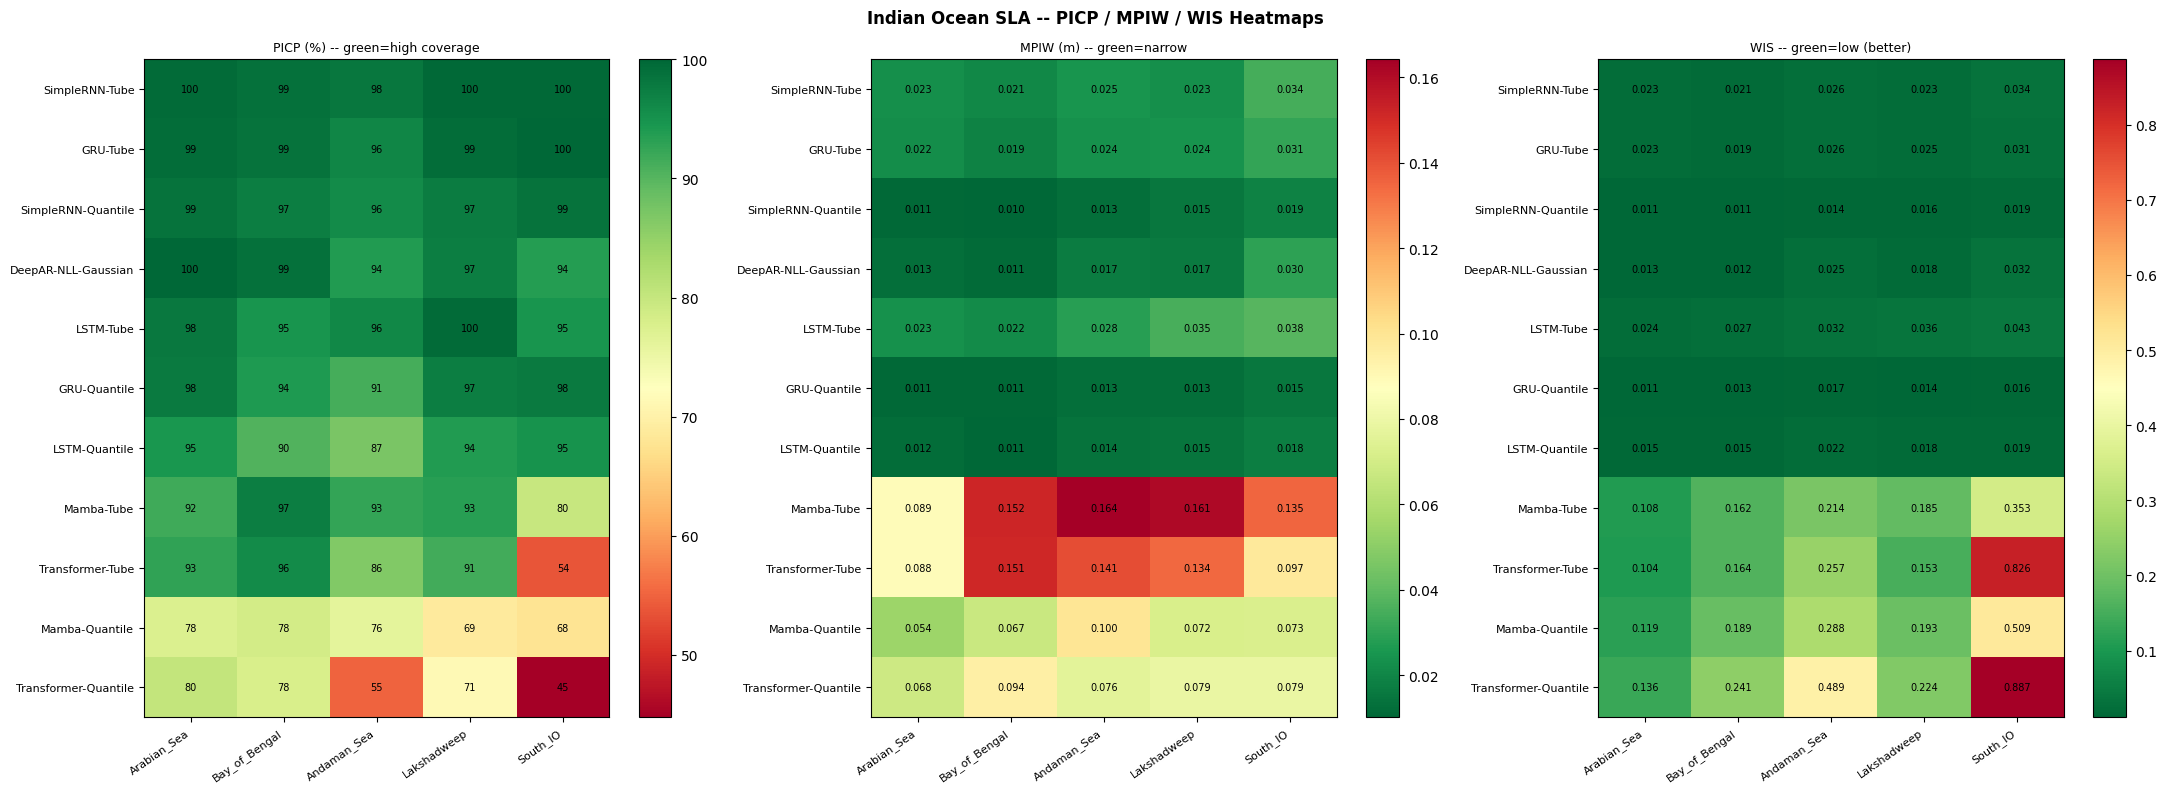

Saved: c:\Users\DA IICT K\Desktop\BMP_files\results_IndianOcean/heatmap_picp_mpiw_wis.png


In [11]:
# Cell 4 — Heatmaps: PICP and WIS
LOCS  = ['Arabian_Sea','Bay_of_Bengal','Andaman_Sea','Lakshadweep','South_IO']
mods  = df_best.groupby('model')['avg_picp'].mean().sort_values(ascending=False).index.tolist()

picp_m = np.full((len(mods), len(LOCS)), np.nan)
mpiw_m = np.full((len(mods), len(LOCS)), np.nan)
wis_m  = np.full((len(mods), len(LOCS)), np.nan)
for i,m in enumerate(mods):
    for j,l in enumerate(LOCS):
        row = df_best[(df_best['model']==m)&(df_best['location']==l)]
        if len(row):
            picp_m[i,j] = float(row['avg_picp']); mpiw_m[i,j] = float(row['avg_mpiw'])
            if 'avg_wis' in row.columns: wis_m[i,j] = float(row['avg_wis'])

fig, axes = plt.subplots(1, 3, figsize=(22, max(4, len(mods)*0.55+2)))
for ax, mat, title, cmap, fmt in [
    (axes[0], picp_m, 'PICP (%) -- green=high coverage', 'RdYlGn', '{:.0f}'),
    (axes[1], mpiw_m, 'MPIW (m) -- green=narrow',        'RdYlGn_r', '{:.3f}'),
    (axes[2], wis_m,  'WIS -- green=low (better)',        'RdYlGn_r', '{:.3f}'),
]:
    im = ax.imshow(mat, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(LOCS)));  ax.set_xticklabels(LOCS, rotation=35, ha='right', fontsize=8)
    ax.set_yticks(range(len(mods)));  ax.set_yticklabels(mods, fontsize=8)
    ax.set_title(title, fontsize=9)
    plt.colorbar(im, ax=ax)
    for i in range(len(mods)):
        for j in range(len(LOCS)):
            if not np.isnan(mat[i,j]):
                ax.text(j,i,fmt.format(mat[i,j]),ha='center',va='center',fontsize=7)

fig.suptitle('Indian Ocean SLA -- PICP / MPIW / WIS Heatmaps', fontsize=12, fontweight='bold')
plt.tight_layout()
fp = os.path.join(SAVE_DIR, 'heatmap_picp_mpiw_wis.png')
plt.savefig(fp, dpi=140, bbox_inches='tight'); plt.show(); print(f'Saved: {fp}')

In [7]:
# Cell 5 — Push results to GitHub
# Commits all CSVs and plots from SAVE_DIR to your GitHub repo.
# Requirements:
#   1. Git installed (VS Code lab PC: should already be present)
#   2. REPO_DIR points to your cloned repo folder
#   3. You have push access (SSH key or PAT configured)
#
# On Colab: git push requires PAT auth (replace YOUR_PAT below)

import subprocess, shutil, os

REPO_DIR    = r'https://github.com/Bhavya-2805/Ocean-Probabilistic-Forecasting.git'  # <── SET THIS to your local repo path
RESULTS_DIR = os.path.join(REPO_DIR, 'results', 'IndianOcean')
os.makedirs(RESULTS_DIR, exist_ok=True)

# Copy all output files to the repo results folder
copied = []
for fname in os.listdir(SAVE_DIR):
    if fname.endswith(('.csv', '.png')):
        src = os.path.join(SAVE_DIR, fname)
        dst = os.path.join(RESULTS_DIR, fname)
        shutil.copy2(src, dst)
        copied.append(fname)
print(f'Copied {len(copied)} files to {RESULTS_DIR}')

def run_git(cmd, cwd):
    result = subprocess.run(cmd, cwd=cwd, capture_output=True, text=True)
    if result.returncode != 0:
        print(f'  GIT ERROR: {result.stderr.strip()}')
    else:
        print(f'  OK: {result.stdout.strip() or cmd[-1]}')
    return result.returncode == 0

import datetime
commit_msg = f'Add Indian Ocean SLA results — {datetime.datetime.now().strftime("%Y-%m-%d %H:%M")}'

print('\nCommitting to GitHub...')
run_git(['git', 'add', 'results/IndianOcean/'], REPO_DIR)
run_git(['git', 'commit', '-m', commit_msg],    REPO_DIR)
run_git(['git', 'push'],                         REPO_DIR)
print('\nDone. Check your GitHub repo.')

OSError: [WinError 123] The filename, directory name, or volume label syntax is incorrect: 'https:'